/tmp/ipykernel_31962/35748648.py:35: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(f"../data/poplation/{fname}.txt", encoding="shift-jis", sep=",", header=1)
/usr/local/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: One or several characters couldn't be converted correctly from SJIS to UTF-8.  This warning will not be emitted anymore
  return ogr_read(
/tmp/ipykernel_31962/35748648.py:104: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


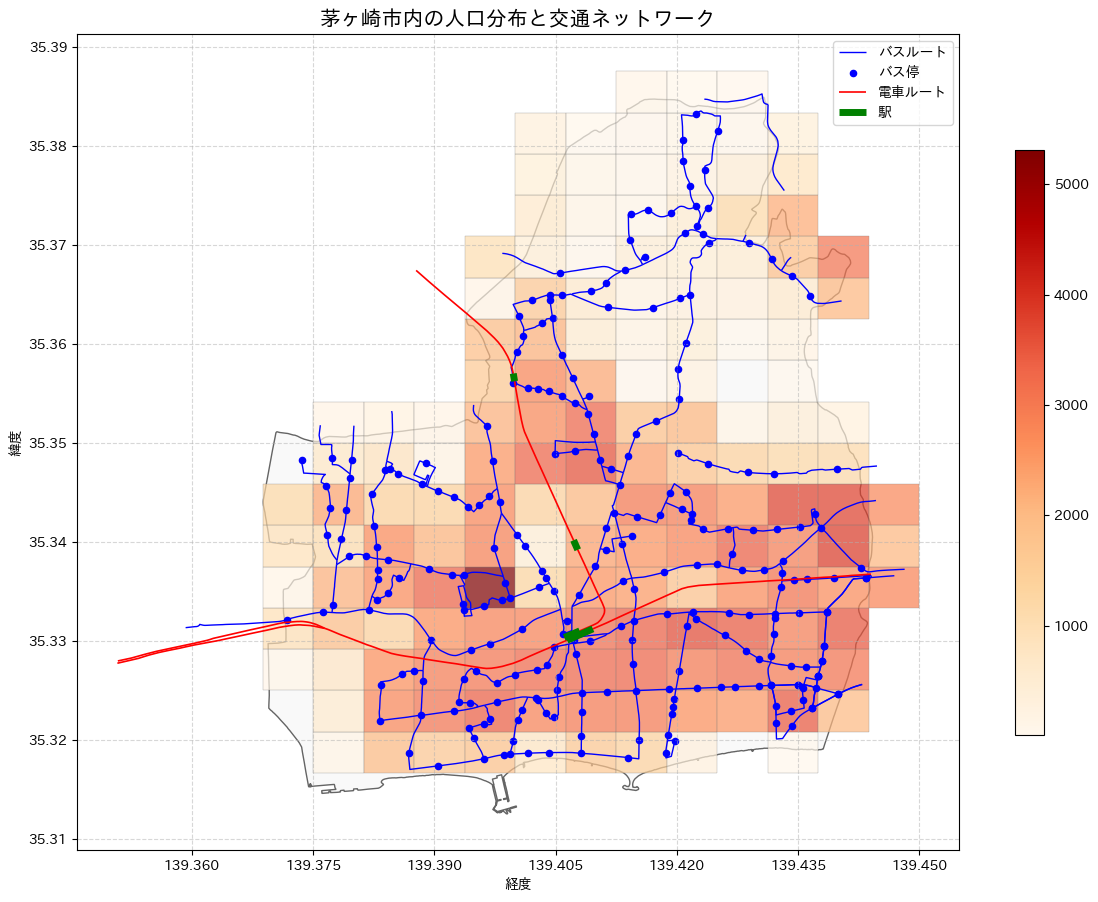

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. メッシュデータの読み込みと統合
# ==========================================
mesh_files = [
    "../data/tmp/merge/MESH05239.shp",
    "../data/tmp/merge/MESH05238.shp",
    "../data/tmp/merge/MESH05339.shp",
    "../data/tmp/merge/MESH05338.shp",
]
mesh_gdf = pd.concat([gpd.read_file(f) for f in mesh_files], ignore_index=True)

# 測地系を統一（JGD2011 EPSG:6668）
target_crs = "EPSG:6668"
mesh_gdf = mesh_gdf.to_crs(target_crs)
mesh_gdf["KEY_CODE"] = mesh_gdf["KEY_CODE"].astype(str)

# ==========================================
# 2. 人口データの読み込みと統合
# ==========================================
pop_files = [
    "tblT001101H5336", "tblT001101H5337", "tblT001101H5338",
    "tblT001101H5339", "tblT001101H5340", "tblT001101H5332",
     "tblT001101H5334", "tblT001101H5335",
    "tblT001101H5238", "tblT001101H5239",
]

pop_dfs = []
for fname in pop_files:
    df = pd.read_table(f"../data/poplation/{fname}.txt", encoding="shift-jis", sep=",", header=1)
    df.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
    df["KEY_CODE"] = df["KEY_CODE"].astype(str)
    df.columns = df.columns.str.strip()
    pop_dfs.append(df)

pop_df = pd.concat(pop_dfs, ignore_index=True)

# ==========================================
# 3. 茅ヶ崎市ポリゴンの抽出
# ==========================================
kanagawa_gdf = gpd.read_file("../data/kanagawa_porigon/kanagawa.shp")
if kanagawa_gdf.crs is None:
    kanagawa_gdf.set_crs(target_crs, inplace=True)
kanagawa_gdf = kanagawa_gdf.to_crs(target_crs)
chigasaki_polygon = kanagawa_gdf.iloc[[880]]

# ==========================================
# 4. メッシュと人口データの結合
# ==========================================
pop_mesh_gdf = pd.merge(mesh_gdf, pop_df, on="KEY_CODE")

# ==========================================
# 5. 茅ヶ崎市内のデータ抽出（空間結合）
# ==========================================
chigasaki_pop_mesh_gdf = gpd.sjoin(pop_mesh_gdf, chigasaki_polygon, how="inner", predicate="intersects")

# 駅とバス停の読み込み・抽出
train_stop_gdf = gpd.read_file("../data/train_stop/N02-22_Station.shp").to_crs(target_crs)
bus_stop_gdf = gpd.read_file("../data/bus_stop/busstop.shp").to_crs(target_crs)
chigasaki_train_stop_gdf = gpd.sjoin(train_stop_gdf, chigasaki_polygon, how="inner", predicate="intersects")
chigasaki_bus_stop_gdf = gpd.sjoin(bus_stop_gdf, chigasaki_polygon, how="inner", predicate="intersects")

# 電車とバスのルート読み込み・抽出
train_route_gdf = gpd.read_file("../data/train_stop/N02-22_RailroadSection.shp").to_crs(target_crs)
bus_route_gdf = gpd.read_file("../data/bus_route/busroute.shp").to_crs(target_crs)
chigasaki_train_route_gdf = gpd.sjoin(train_route_gdf, chigasaki_polygon, how="inner", predicate="intersects")
chigasaki_bus_route_gdf = gpd.sjoin(bus_route_gdf, chigasaki_polygon, how="inner", predicate="intersects")

# ==========================================
# 6. プロット（可視化）
# ==========================================
fig, ax = plt.subplots(figsize=(12, 12))

# 茅ヶ崎市ポリゴン
chigasaki_polygon.plot(ax=ax, color="whitesmoke", edgecolor="black", alpha=0.6, label="茅ヶ崎市")

# メッシュ（人口で色分け）
chigasaki_pop_mesh_gdf.plot(
    ax=ax,
    column=chigasaki_pop_mesh_gdf.columns[10],  # 適切な列名に変更推奨
    cmap="OrRd",
    legend=True,
    legend_kwds={"shrink": 0.5},
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.3
)

# 駅・バス停・ルート
chigasaki_bus_route_gdf.plot(ax=ax, color="blue", linewidth=1, label="バスルート")
chigasaki_bus_stop_gdf.plot(ax=ax, color="blue", markersize=20, label="バス停")
chigasaki_train_route_gdf.plot(ax=ax, color="red", linewidth=1.2, label="電車ルート")
chigasaki_train_stop_gdf.plot(ax=ax, color="green", markersize=120, label="駅",linewidth=5)

# 軸と凡例
ax.set_title("茅ヶ崎市内の人口分布と交通ネットワーク", fontsize=15)
ax.set_xlabel("経度")
ax.set_ylabel("緯度")
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
!sudo pip install python-louvain
import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import community as community_louvain

# 路線のジオメトリから始点・終点を取得
edges = []
for geom in chigasaki_bus_route_gdf.geometry:
    if geom.geom_type == 'LineString':
        coords = list(geom.coords)
        edges.append((tuple(coords[0]), tuple(coords[-1])))

# ネットワーク作成
G = nx.Graph()
G.add_edges_from(edges)

# 媒介中心性
betweenness = nx.betweenness_centrality(G)

# コミュニティ（解像度高めにして数を増やす）
partition = community_louvain.best_partition(G, resolution=2.0)

# ノード座標と属性
node_df = pd.DataFrame({
    "coords": list(betweenness.keys()),
    "centrality": list(betweenness.values())
})
node_df["x"] = node_df["coords"].apply(lambda p: p[0])
node_df["y"] = node_df["coords"].apply(lambda p: p[1])
node_df["community"] = node_df["coords"].map(partition)

# ノードサイズスケーリング
scaler = MinMaxScaler(feature_range=(10, 100))
node_df["size"] = scaler.fit_transform(node_df[["centrality"]])

# 色設定（tab20を使って色を増やす）
unique_comms = sorted(node_df["community"].unique())
color_map = cm.get_cmap("tab20", len(unique_comms))
colors = {comm: color_map(i) for i, comm in enumerate(unique_comms)}
node_df["color"] = node_df["community"].map(colors)

# 可視化
fig, ax = plt.subplots(figsize=(8, 8))
for _, row in node_df.iterrows():
    ax.scatter(row["x"], row["y"], s=row["size"], color=row["color"], edgecolor="black", zorder=3)

for edge in edges:
    x = [edge[0][0], edge[1][0]]
    y = [edge[0][1], edge[1][1]]
    ax.plot(x, y, color="lightblue", linewidth=1)

ax.set_title("バス路線ネットワーク（媒介中心性と細分化コミュニティ）", fontsize=14)
ax.set_xlabel("経度")
ax.set_ylabel("緯度")

# 茅ヶ崎市ポリゴン
chigasaki_polygon.plot(ax=ax, color="whitesmoke", edgecolor="black", alpha=0.6, label="茅ヶ崎市")

# メッシュ（人口で色分け）
chigasaki_pop_mesh_gdf.plot(
    ax=ax,
    column=chigasaki_pop_mesh_gdf.columns[10],  # 適切な列名に変更推奨
    cmap="OrRd",
    legend=True,
    legend_kwds={"shrink": 0.5},
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.3
)

# 駅・バス停・ルート
chigasaki_bus_route_gdf.plot(ax=ax, color="blue", linewidth=1, label="バスルート")
chigasaki_train_route_gdf.plot(ax=ax, color="red", linewidth=1.2, label="電車ルート")
chigasaki_train_stop_gdf.plot(ax=ax, color="green", markersize=120, label="駅",linewidth=5)

# 軸と凡例
ax.set_title("茅ヶ崎市内の人口分布と交通ネットワーク", fontsize=15)
ax.set_xlabel("経度")
ax.set_ylabel("緯度")
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/bin/bash: line 1: sudo: command not found


AttributeError: module 'community' has no attribute 'best_partition'

In [14]:
import networkx as nx
from shapely.geometry import Point
import community as community_louvain
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# バスルートからネットワーク構築（始点と終点からエッジ生成）
# ==========================================
edges = []
for geom in chigasaki_bus_route_gdf.geometry:
    if geom.geom_type == 'LineString':
        coords = list(geom.coords)
        edges.append((tuple(coords[0]), tuple(coords[-1])))

G = nx.Graph()
G.add_edges_from(edges)

# ==========================================
# 媒介中心性とコミュニティを計算
# ==========================================
betweenness = nx.betweenness_centrality(G)
partition = community_louvain.best_partition(G, resolution=2.0)

# ==========================================
# バス停の座標をノードの形式に揃える（最も近いノードに属性をマッチさせる）
# ==========================================
def find_nearest_node(point, node_list):
    return min(node_list, key=lambda node: Point(node).distance(point))

# バス停ごとに、最も近いノード（ネットワーク上の座標）を見つけて属性を引き継ぐ
chigasaki_bus_stop_gdf = chigasaki_bus_stop_gdf.copy()
chigasaki_bus_stop_gdf["nearest_node"] = chigasaki_bus_stop_gdf.geometry.apply(lambda p: find_nearest_node(p, list(G.nodes)))
chigasaki_bus_stop_gdf["centrality"] = chigasaki_bus_stop_gdf["nearest_node"].map(betweenness)
chigasaki_bus_stop_gdf["community"] = chigasaki_bus_stop_gdf["nearest_node"].map(partition)

# 中心性スコアをサイズスケーリングして「size」列を追加（QGIS用）
scaler = MinMaxScaler((10, 100))
valid_centralities = chigasaki_bus_stop_gdf["centrality"].fillna(0).values.reshape(-1, 1)
chigasaki_bus_stop_gdf["size"] = scaler.fit_transform(valid_centralities)

# 不要な列を整理して保存（例：`index_right`がある場合削除）
if "index_right" in chigasaki_bus_stop_gdf.columns:
    chigasaki_bus_stop_gdf.drop(columns=["index_right"], inplace=True)

# ==========================================
# QGISで使えるGeoJSONとして保存
# ==========================================
chigasaki_bus_stop_gdf.to_file("../data/chigasaki/chigasaki_bus_stop_with_network.geojson", driver="GeoJSON")
print("✅ QGIS用GeoJSON保存完了：chigasaki_bus_stop_with_network.geojson")

AttributeError: module 'community' has no attribute 'best_partition'

# データの保存

In [15]:
# 出力フォルダの指定（なければ作成）
import os
output_dir = "../data/chigasaki"
os.makedirs(output_dir, exist_ok=True)

# 茅ヶ崎市の各データをGeoJSONで保存
chigasaki_polygon.to_file(f"{output_dir}/chigasaki_polygon.geojson", driver="GeoJSON")
chigasaki_pop_mesh_gdf.to_file(f"{output_dir}/chigasaki_pop_mesh.geojson", driver="GeoJSON")
chigasaki_train_stop_gdf.to_file(f"{output_dir}/chigasaki_train_stop.geojson", driver="GeoJSON")
chigasaki_bus_stop_gdf.to_file(f"{output_dir}/chigasaki_bus_stop.geojson", driver="GeoJSON")
chigasaki_train_route_gdf.to_file(f"{output_dir}/chigasaki_train_route.geojson", driver="GeoJSON")
chigasaki_bus_route_gdf.to_file(f"{output_dir}/chigasaki_bus_route.geojson", driver="GeoJSON")


変数について
- chigasaki_polygon => 茅ヶ崎市のポリゴンデータ
- chigasaki_pop_mesh_gdf => 茅ヶ崎市の500mメッシュないの人口
- chigasaki_train_stop_gdf => 茅ヶ崎市内にある電車駅の緯度経度
- chigasaki_bus_stop_gdf => 茅ヶ崎市内にあるバス停の緯度経度
- chigasaki_train_route_gdf => 茅ヶ崎市内の電車の路線
- chigasaki_bus_route_gdf => 茅ヶ崎市内のバスの路線

# 可視化

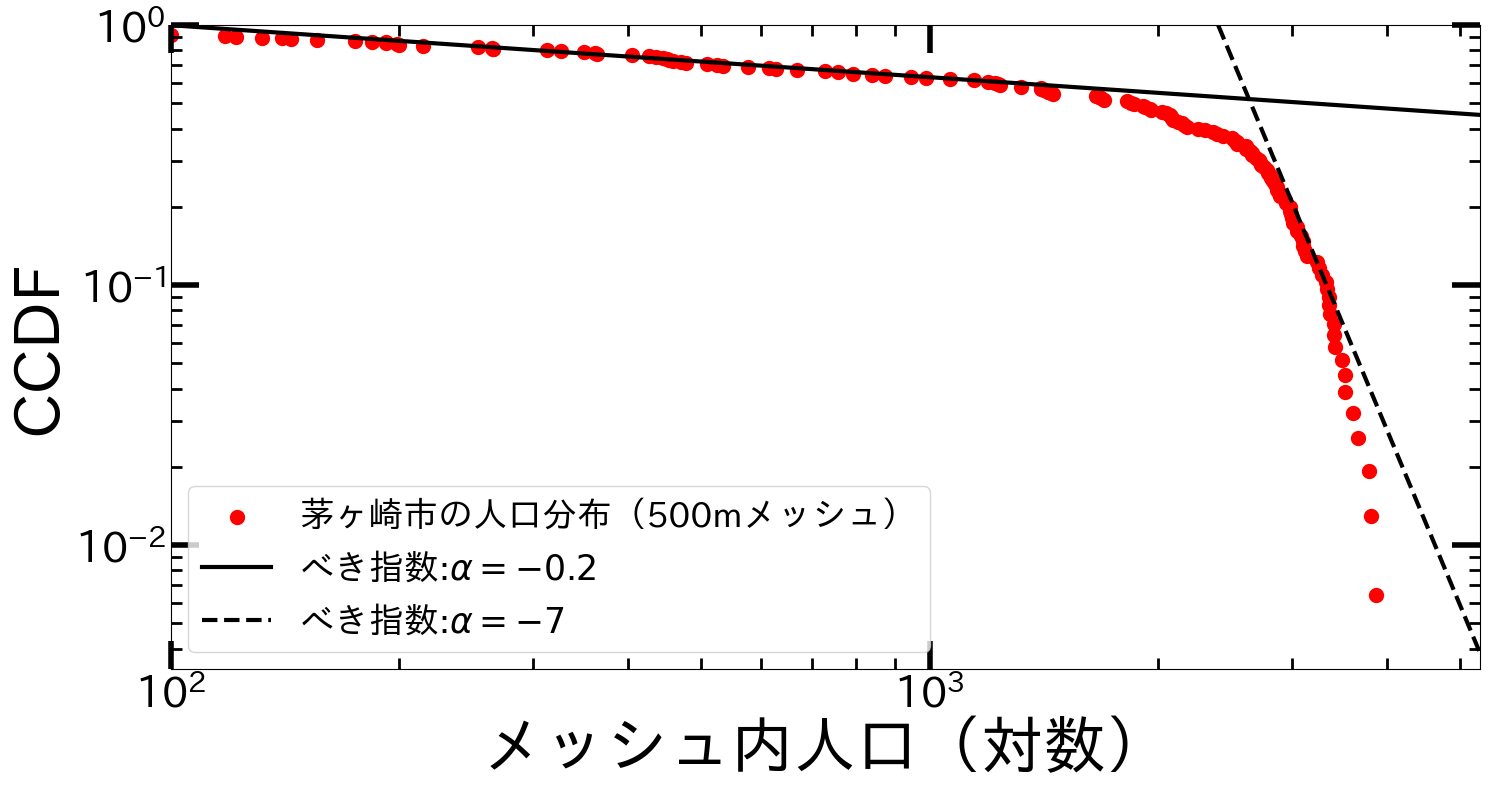

In [16]:
import matplotlib.pyplot as plt

# 再利用のために前回のフィッティング結果から人口データを取得
pop_column = "人口（総数）"
population = chigasaki_pop_mesh_gdf[pop_column].dropna()
population = population[population > 0]
population_sorted = population.sort_values()

# CCDF（相補累積分布関数）を計算
ccdf_y = 1.0 - population_sorted.rank(method='first') / len(population_sorted)

# プロット
plt.figure(figsize=(15, 8))
plt.scatter(population_sorted, ccdf_y, color='red', label='茅ヶ崎市の人口分布（500mメッシュ）', lw=5)
###### べき分布の最尤推定 #####
# べき指数（パワー・ロー指数）を設定
alpha = 0.2
# 新しい最小値を設定
new_xmin = 100
# x軸の値を生成
x = np.linspace(new_xmin, 10000, 10000)  # 新しい最小値から10までの範囲を1000分割
# 平行移動したCCDFを計算
ccdf = (x / new_xmin)**(-alpha)
# グラフを描画
plt.plot(x, ccdf,color="black",lw=3,label=r"べき指数:$\alpha=-0.2$")
#############################

###### べき分布の最尤推定 #####
# べき指数（パワー・ロー指数）を設定
alpha = 7
# 新しい最小値を設定
new_xmin = 2400
# x軸の値を生成
x = np.linspace(new_xmin, 100000, 1000000)  # 新しい最小値から10までの範囲を1000分割
# 平行移動したCCDFを計算
ccdf = (x / new_xmin)**(-alpha)
# グラフを描画
plt.plot(x, ccdf,color="black",lw=3,label=r"べき指数:$\alpha=-7$",linestyle="--")
#############################

plt.xscale('log')
plt.yscale('log')
plt.ylim(1/300, 1)
plt.xlim(100, population_sorted.max())
plt.xlabel('メッシュ内人口（対数）', fontsize=45)
plt.ylabel('CCDF', fontsize=45)
plt.tick_params(labelsize=30, which='major', width=4, length=20, direction='in', top=True, right=True)
plt.tick_params(labelsize=30, which='minor', width=2, length=8, direction='in', top=True, right=True)
plt.minorticks_on()
plt.legend(loc='lower left', fontsize=25)
plt.tight_layout()
plt.show()

## メッシュ内の人口について

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 必要な列の確認（名前が異なる場合は変更してください）
population_column = "人口（総数）"  # 実際の列名を確認

# 必要な列のみ抽出 & ゼロ除外（対数変換のため）
df = mesh_with_bus[[population_column, "バス停数"]].copy()
df = df[(df["バス停数"] > 0) & (df[population_column] > 0)]

# 両対数変換
df["log_バス停数"] = np.log(df["バス停数"])
df["log_人口"] = np.log(df[population_column])

# 回帰モデル作成
X = df[["log_バス停数"]]
y = df["log_人口"]
model = LinearRegression()
model.fit(X, y)

# 回帰直線
x_vals = np.linspace(X.min(), X.max(), 100)
y_vals = model.predict(x_vals)

# 描画
plt.figure(figsize=(8, 6))
plt.scatter(df["バス停数"], df[population_column], alpha=0.6, label="データ", color="teal")
plt.plot(np.exp(x_vals), np.exp(y_vals), color="red",
         label=f"回帰線: y = exp({model.intercept_:.2f}) * x^{model.coef_[0]:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("メッシュ内のバス停数（対数スケール）", fontsize=12)
plt.ylabel("メッシュ内の人口（対数スケール）", fontsize=12)
plt.title("メッシュごとのバス停数と人口の散布図と対数回帰", fontsize=14)
plt.legend()
plt.ylim(100,5000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 回帰係数の解釈
slope = model.coef_[0]
intercept = model.intercept_
増加率 = (np.exp(slope) - 1) * 100

print(fr"$\text{{人口}} = \exp({intercept:.2f}) \times (\text{{バス停数}})^{{{slope:.2f}}}$")

print(f"解釈: バス停が1つ増えると、人口は約 {増加率:.2f}% 増加する（対数スケール上）")


NameError: name 'mesh_with_bus' is not defined

/tmp/ipykernel_31962/1294931967.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  chigasaki_pop_mesh_gdf["center"] = chigasaki_pop_mesh_gdf.geometry.centroid
/tmp/ipykernel_31962/1294931967.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  train_stop_union = chigasaki_train_stop_gdf.unary_union
/tmp/ipykernel_31962/1294931967.py:41: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centers_gdf["dist_to_train"] = centers_gdf.distance(train_stop_union)
/tmp/ipykernel_31962/1294931967.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bus_stop_union = chigasaki_bus_stop_gdf.unary_union
/tmp/ipyke

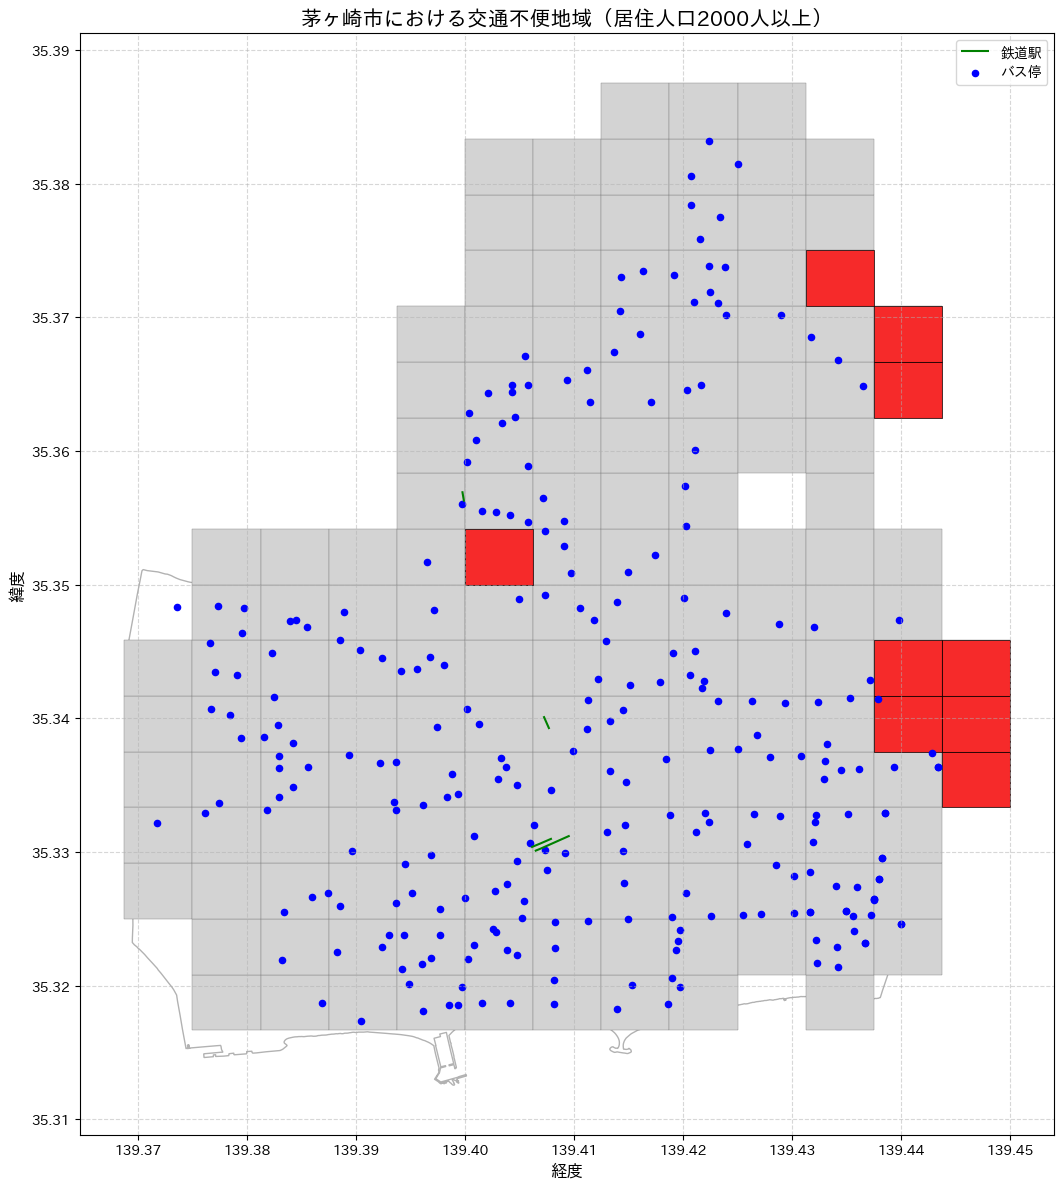

✅ 交通不便地域をGeoJSONとして保存しました。


In [20]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ========================
# 0. CRSをEPSG:6668に統一
# ========================
target_crs = "EPSG:6668"

gdf_list = [
    chigasaki_pop_mesh_gdf, chigasaki_train_stop_gdf,
    chigasaki_bus_stop_gdf, chigasaki_polygon
]

chigasaki_pop_mesh_gdf, chigasaki_train_stop_gdf, chigasaki_bus_stop_gdf, chigasaki_polygon = [
    gdf.to_crs(target_crs) for gdf in gdf_list
]

# ========================
# 1. メッシュの中心点を取得
# ========================
chigasaki_pop_mesh_gdf = chigasaki_pop_mesh_gdf.copy()
chigasaki_pop_mesh_gdf["center"] = chigasaki_pop_mesh_gdf.geometry.centroid
centers_gdf = gpd.GeoDataFrame(
    chigasaki_pop_mesh_gdf.drop(columns="geometry"),
    geometry=chigasaki_pop_mesh_gdf["center"],
    crs=target_crs
)

# ========================
# 2. 人口カラムを指定（例：'人口（総数）'）
# ========================
population_column = "人口（総数）"  # カラム名を明示

# ========================
# 3. 条件を満たすメッシュを抽出
# ========================
condition_pop = centers_gdf[population_column] >= 2000

train_stop_union = chigasaki_train_stop_gdf.unary_union
centers_gdf["dist_to_train"] = centers_gdf.distance(train_stop_union)
condition_train = centers_gdf["dist_to_train"] > 0.003

bus_stop_union = chigasaki_bus_stop_gdf.unary_union
centers_gdf["dist_to_bus"] = centers_gdf.distance(bus_stop_union)
condition_bus = centers_gdf["dist_to_bus"] > 0.003

# ========================
# 4. 交通不便地域の抽出
# ========================
unserved_mesh_gdf = centers_gdf[condition_pop & condition_train & condition_bus]

highlight_gdf = chigasaki_pop_mesh_gdf[
    chigasaki_pop_mesh_gdf["KEY_CODE"].isin(unserved_mesh_gdf["KEY_CODE"])
]

# ========================
# 5. 可視化
# ========================
fig, ax = plt.subplots(figsize=(12, 12))
chigasaki_polygon.plot(ax=ax, color="white", edgecolor="black", alpha=0.3)
chigasaki_pop_mesh_gdf.plot(ax=ax, color="lightgray", edgecolor="gray", linewidth=0.3, label="500mメッシュ")
highlight_gdf.plot(ax=ax, color="red", edgecolor="black", linewidth=0.6, alpha=0.8, label="交通不便地域")
chigasaki_train_stop_gdf.plot(ax=ax, color="green", markersize=60, label="鉄道駅")
chigasaki_bus_stop_gdf.plot(ax=ax, color="blue", markersize=20, label="バス停")

ax.set_title("茅ヶ崎市における交通不便地域（居住人口2000人以上）", fontsize=15)
ax.set_xlabel("経度", fontsize=12)
ax.set_ylabel("緯度", fontsize=12)
ax.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### geojsonに追加
highlight_gdf = highlight_gdf.drop(columns=["center"])
highlight_gdf.to_file("../data/chigasaki/unserved_areas.geojson", driver="GeoJSON", encoding='utf-8')
print("✅ 交通不便地域をGeoJSONとして保存しました。")


In [ ]:
chigasaki

,P11_001,P11_002,P11_003_01,P11_003_02,P11_003_03,P11_003_04,P11_003_05,P11_003_06,P11_003_07,P11_003_08,...,P11_004_32,P11_004_33,P11_004_34,P11_004_35,P11_005,geometry,nearest_node,centrality,community,size
6988,芹沢台田（斎場入口）,神奈川中央交通（株）,北部循環市立病院線,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.42236 35.3832),"(139.4223603194362, 35.383195715580236)",0.000107,5,10.025327
7053,芹沢細谷入口,神奈川中央交通（株）,北部循環市立病院線,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.42504 35.38147),"(139.42504183683656, 35.38147446437121)",0.005720,5,11.350783
7091,芹沢細紺,神奈川中央交通（株）,北部循環市立病院線,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.42072 35.38054),"(139.42072452842643, 35.38053860016477)",0.000179,5,10.042212
7154,芹沢中部下,神奈川中央交通（株）,北部循環市立病院線,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.42076 35.37843),"(139.42075812005368, 35.37842851749533)",0.005863,5,11.384553
7185,芹沢スポーツ広場,神奈川中央交通（株）,北部循環市立病院線,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.42343 35.37752),"(139.42342771684196, 35.37752166827582)",0.011404,5,12.693124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9174,サザンビーチ入口,神奈川中央交通（株）,中海岸南湖循環私立病院線,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.39935 35.31858),"(139.3993516302957, 35.31857543394498)",0.031910,18,17.535751
9176,海水浴場前,神奈川中央交通（株）,茅37,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.39857 35.31852),"(139.39856922637736, 35.318520168425174)",0.025974,18,16.133962
9181,ヘッドランド入口,神奈川中央交通（株）,茅09,None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.41398 35.31822),"(139.41398482032426, 35.318221658322194)",0.036472,19,18.613071
9184,西浜,神奈川中央交通（株）,"茅37,中海岸南湖循環私立病院線",None,None,None,None,None,None,None,...,None,None,None,None,None,POINT (139.39612 35.31811),"(139.39612447284605, 35.3181118691545)",0.027631,18,16.525126
